# Descripcion del proyecto:

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estás pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.



# 1. Apertura de archivos y estudio de informacion general

In [ ]:
# cargar librerias
import pandas as pd
import numpy as np
from scipy import stats as st
import math
from matplotlib import pyplot as plt
from scipy.stats import t, ttest_ind

In [ ]:
# cargar archivo
games = pd.read_csv('/datasets/games.csv')

In [ ]:
# verificar informacion de archivo
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
# Verificacion de informacion de cada columna
games.sample(20)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1572,Rockstar Games presents Table Tennis,Wii,2007.0,Sports,0.39,0.72,0.00,0.15,68.0,5.8,E
7016,Madagascar: Escape 2 Africa,PS3,2008.0,Action,0.12,0.08,0.00,0.03,58.0,6.8,E10+
889,Tom Clancy's Ghost Recon,PS2,2002.0,Shooter,1.42,0.40,0.00,0.12,63.0,8.3,M
8884,eJay Clubworld,PS2,NaN,Misc,0.07,0.06,0.00,0.02,69.0,8.6,E
6918,X-Men: Destiny,X360,2011.0,Action,0.18,0.04,0.00,0.02,47.0,5,T
4721,Buzz! Junior: Jungle Party,PS2,2006.0,Misc,0.20,0.16,0.00,0.05,NaN,NaN,NaN
5375,Alien's Return,2600,1982.0,Action,0.32,0.02,0.00,0.00,NaN,NaN,NaN
227,Tony Hawk's Pro Skater 2,PS,2000.0,Sports,3.05,1.41,0.02,0.20,98.0,7.7,T
12766,Rugby World Cup 2015,PS3,2015.0,Sports,0.00,0.05,0.00,0.01,NaN,tbd,E
6868,Valhalla Knights,PSP,2006.0,Role-Playing,0.15,0.00,0.07,0.01,53.0,6.3,E10+


Analisis de los datos:

Se tienen que hacer los ajustes de los nombres de las columnas. <br>
Se observa que se tienen que hacer ajustes en el año, ya que esta como flotante. <br>
Se tienen que verificar que no hay nombres repetidos o tratar los faltantes para los juegos. <br>
De igual manera se tiene que tratar critic score, user score y rating. <br>

# 2. Preparacion de datos

In [ ]:
# Cambiar los titulos de columnas a minusculas
games.columns = games.columns.str.lower()

In [ ]:
# conversion de datos en los necesarios
games['year_of_release'].fillna(-1,inplace=True)
games['year_of_release'] = games['year_of_release'].astype(int)
games['user_score'].fillna(-1,inplace=True)
games['user_score'].replace('tbd',-1,inplace=True)
games['user_score'] = games['user_score'].astype(float)
games['critic_score'].fillna(-1,inplace=True)
games['rating'].fillna('unknown',inplace=True)
games.dropna(subset=['name'],inplace=True)
games.sample(15)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
6382,Jurassic Park: Operation Genesis,PS2,2003,Simulation,0.13,0.10,0.00,0.03,75.0,8.9,T
9940,Wipeout 2,PS3,2011,Misc,0.11,0.00,0.00,0.01,-1.0,-1.0,E10+
8431,25 to Life,XB,2006,Shooter,0.12,0.04,0.00,0.01,41.0,7.2,M
185,New Super Mario Bros. U,WiiU,2012,Platform,2.30,1.34,1.27,0.32,84.0,8.1,E
11953,Galerians: Ash,PS2,2002,Adventure,0.03,0.03,0.00,0.01,50.0,7.9,T
6771,Jikkyou Powerful Pro Yakyuu 2001,PS,2001,Sports,0.00,0.00,0.23,0.02,-1.0,-1.0,unknown
4032,The Sims,GC,2003,Simulation,0.35,0.13,0.00,0.01,85.0,7.7,T
548,Tekken 6,PS3,2009,Fighting,1.20,0.97,0.17,0.42,79.0,7.4,T
14265,Dream C Club Zero,X360,2011,Simulation,0.00,0.00,0.03,0.00,-1.0,-1.0,unknown
14151,Gekiatsu!! Pachi Game Tamashi: CR Evangelion -...,PS3,2010,Misc,0.00,0.00,0.03,0.00,-1.0,-1.0,unknown


Descripcion de cambios realizados:

-Se cambio la columna de year of release a entero, ya que no es necesario tenerla en flotante, tambien los valores ausentes se dejaron en -1 para evitar analisis incorrectos posteriormente y para identificar facilmente los valores ausentes. <br>
-Se cambio la columna user score a flotante y se reemplazaron los valores ausentes y tbd por -1 para evitar afectar posteriormente algun analisis en esta columna. Es mas facil identificar los valores ausentes por el -1. <br>
-Se reemplazaron los valores ausentes en rating por unknown para evitar afectar el analisis posteriormente sobre esta columna. <br>
-Se eliminaron las filas que no tienen informacion del juego ni de la plataforma para evitar afectar los resultados del analisis. <br>

In [ ]:
# calculo de las ventas por juego en una columna nueva 
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
print(games.head(10))

                        name platform  year_of_release         genre  \
0                 Wii Sports      Wii             2006        Sports   
1          Super Mario Bros.      NES             1985      Platform   
2             Mario Kart Wii      Wii             2008        Racing   
3          Wii Sports Resort      Wii             2009        Sports   
4   Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                     Tetris       GB             1989        Puzzle   
6      New Super Mario Bros.       DS             2006      Platform   
7                   Wii Play      Wii             2006          Misc   
8  New Super Mario Bros. Wii      Wii             2009      Platform   
9                  Duck Hunt      NES             1984       Shooter   

   na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
0     41.36     28.96      3.77         8.45          76.0         8.0   
1     29.08      3.58      6.81         0.77          -1.0 

# 3. Analisis de datos

In [ ]:
# Juegos lanzados por cada año
games.groupby('year_of_release')['name'].count().sort_values(ascending=False)

year_of_release
 2008    1427
 2009    1426
 2010    1255
 2007    1197
 2011    1136
 2006    1006
 2005     939
 2002     829
 2003     775
 2004     762
 2012     653
 2015     606
 2014     581
 2013     544
 2016     502
 2001     482
 1998     379
 2000     350
 1999     338
 1997     289
-1        269
 1996     263
 1995     219
 1994     121
 1993      60
 1981      46
 1992      43
 1991      41
 1982      36
 1986      21
 1989      17
 1983      17
 1987      16
 1990      16
 1988      15
 1985      14
 1984      14
 1980       9
Name: name, dtype: int64

Con los datos mostrados anteriormente, nos da una idea de como han incrementado los juegos lanzados por año pero hace falta analizar mas informacion de las ventas por plataforma, asi como analisis de las plataformas, ratings, etc.

In [ ]:
# Analisis de la venta por plataforma
sales_by_platform = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
print(sales_by_platform)

   platform  total_sales
0       PS2      1255.77
1      X360       971.42
2       PS3       939.65
3       Wii       907.51
4        DS       806.12
5        PS       730.86
6       GBA       317.85
7       PS4       314.14
8       PSP       294.05
9        PC       259.52
10      3DS       259.00
11       XB       257.74
12       GB       255.46
13      NES       251.05
14      N64       218.68
15     SNES       200.04
16       GC       198.93
17     XOne       159.32
18     2600        96.98
19     WiiU        82.19
20      PSV        54.07
21      SAT        33.59
22      GEN        28.35
23       DC        15.95
24      SCD         1.86
25       NG         1.44
26       WS         1.42
27     TG16         0.16
28      3DO         0.10
29       GG         0.04
30     PCFX         0.03


platform             DS      PS     PS2     PS3     Wii    X360
year_of_release                                                
1985               0.02     NaN     NaN     NaN     NaN     NaN
1994                NaN    6.03     NaN     NaN     NaN     NaN
1995                NaN   35.96     NaN     NaN     NaN     NaN
1996                NaN   94.70     NaN     NaN     NaN     NaN
1997                NaN  136.17     NaN     NaN     NaN     NaN
1998                NaN  169.49     NaN     NaN     NaN     NaN
1999                NaN  144.53     NaN     NaN     NaN     NaN
2000                NaN   96.37   39.17     NaN     NaN     NaN
2001                NaN   35.59  166.43     NaN     NaN     NaN
2002                NaN    6.67  205.38     NaN     NaN     NaN
2003                NaN    2.07  184.31     NaN     NaN     NaN
2004              17.27     NaN  211.81     NaN     NaN     NaN
2005             130.14     NaN  160.66     NaN     NaN    8.25
2006             119.81     NaN  103.42 

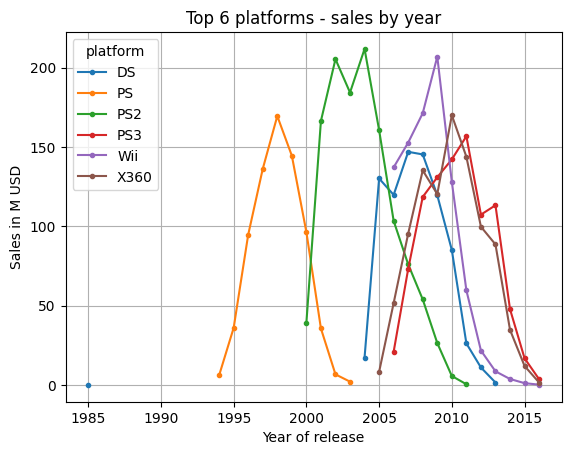

In [ ]:
# Analisis de ventas por año y plataformas mas vendidas
top6_sales = sales_by_platform['platform'][:6]
top6_sales_data = games[(games['platform'].isin(top6_sales)) & (games['year_of_release'] > 0)]
top6_sales_filtered_data = pd.pivot_table(top6_sales_data, index=['year_of_release'],columns='platform',values='total_sales',aggfunc='sum')
print(top6_sales_filtered_data)
top6_sales_filtered_data.plot(style='.-')
plt.title('Top 6 platforms - sales by year')
plt.xlabel('Year of release')
plt.ylabel('Sales in M USD')
plt.grid()

platform          2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                                 
1980             11.38   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1981             35.68   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1982             28.88   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1983              5.84   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1984              0.27   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1985              0.45   NaN    NaN   NaN    0.02    NaN    NaN    NaN    NaN   
1986              0.67   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1987              1.94   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1988              0.74   NaN    NaN   NaN     NaN   1.43    NaN    NaN    NaN   
1989              0.63   NaN    NaN   NaN     NaN  64.97    NaN    NaN    NaN   
1990               NaN   NaN

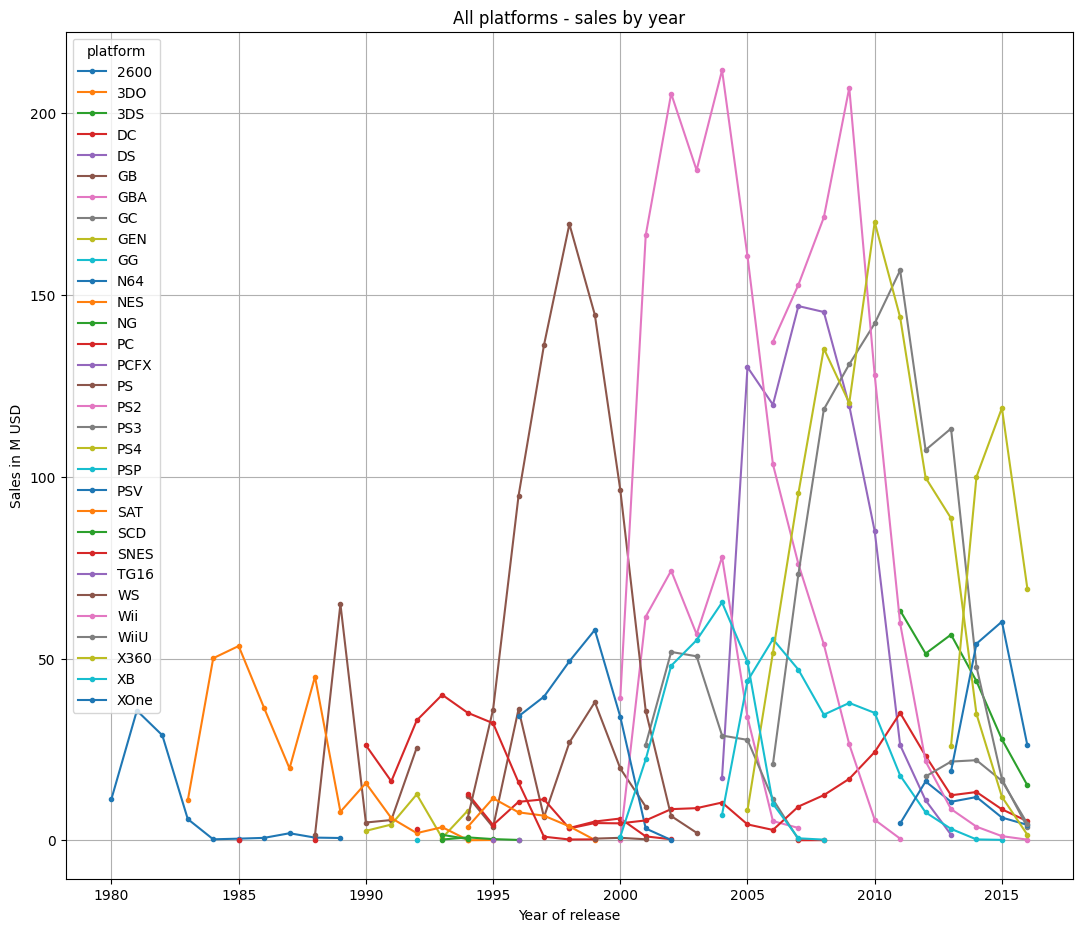

In [ ]:
# Analisis de todas las plataformas populares y con bajas ventas 
platform_filtered = games[games['year_of_release'] > 0]
platform_popularity_by_year = pd.pivot_table(platform_filtered, index=['year_of_release'],columns='platform',values='total_sales',aggfunc='sum')
print(platform_popularity_by_year)
platform_popularity_by_year.plot(style='.-', figsize=(13,11))
plt.title('All platforms - sales by year')
plt.xlabel('Year of release')
plt.ylabel('Sales in M USD')
plt.grid()

Con base en la informacion anterior, se observo que son 6 plataformas las que tienen ventas mayores a 500 millones de USD por lo que esas son las que se seleccionan para el analisis de ventas por año. Al realizar el analisis de esas 6 plataformas por año, se observa que se va dando una transicion entre las plataformas PS, generacion 1, 2 y 3 asi como que la disputa entre diferentes plataformas comienza a partir del 2006. <br>
Posteriormente, se hace el analisis de todas las plataformas con informacion de year of release, en la que se detecta que los picos de ventas se dan en el periodo de 1995 a 2012 y tambien se observa que el tiempo maximo de vida de las plataformas es de 10 años, y para el caso particular de los PS se observa que se dan cierto tipo de transicion al salir una nueva generacion y ese tiempo es de aproximadamente 6-8 años. <br>
Se puede considerar el periodo de 1995 a 2016 para ver predicciones para el 2017. 

platform          3DO    3DS    DC      DS     GB    GBA     GC    N64    NG  \
year_of_release                                                                
1995             0.08    NaN   NaN     NaN   3.60    NaN    NaN    NaN  0.33   
1996              NaN    NaN   NaN     NaN  36.03    NaN    NaN  34.10  0.10   
1997              NaN    NaN   NaN     NaN   6.37    NaN    NaN  39.50   NaN   
1998              NaN    NaN  3.38     NaN  26.90    NaN    NaN  49.24   NaN   
1999              NaN    NaN  5.16     NaN  38.00    NaN    NaN  57.87   NaN   
2000              NaN    NaN  5.99     NaN  19.76   0.07    NaN  33.97   NaN   
2001              NaN    NaN  1.07     NaN   9.24  61.53  26.34   3.25   NaN   
2002              NaN    NaN  0.29     NaN    NaN  74.16  51.81   0.08   NaN   
2003              NaN    NaN   NaN     NaN    NaN  56.67  50.61    NaN   NaN   
2004              NaN    NaN   NaN   17.27    NaN  77.91  28.82    NaN   NaN   
2005              NaN    NaN   NaN  130.

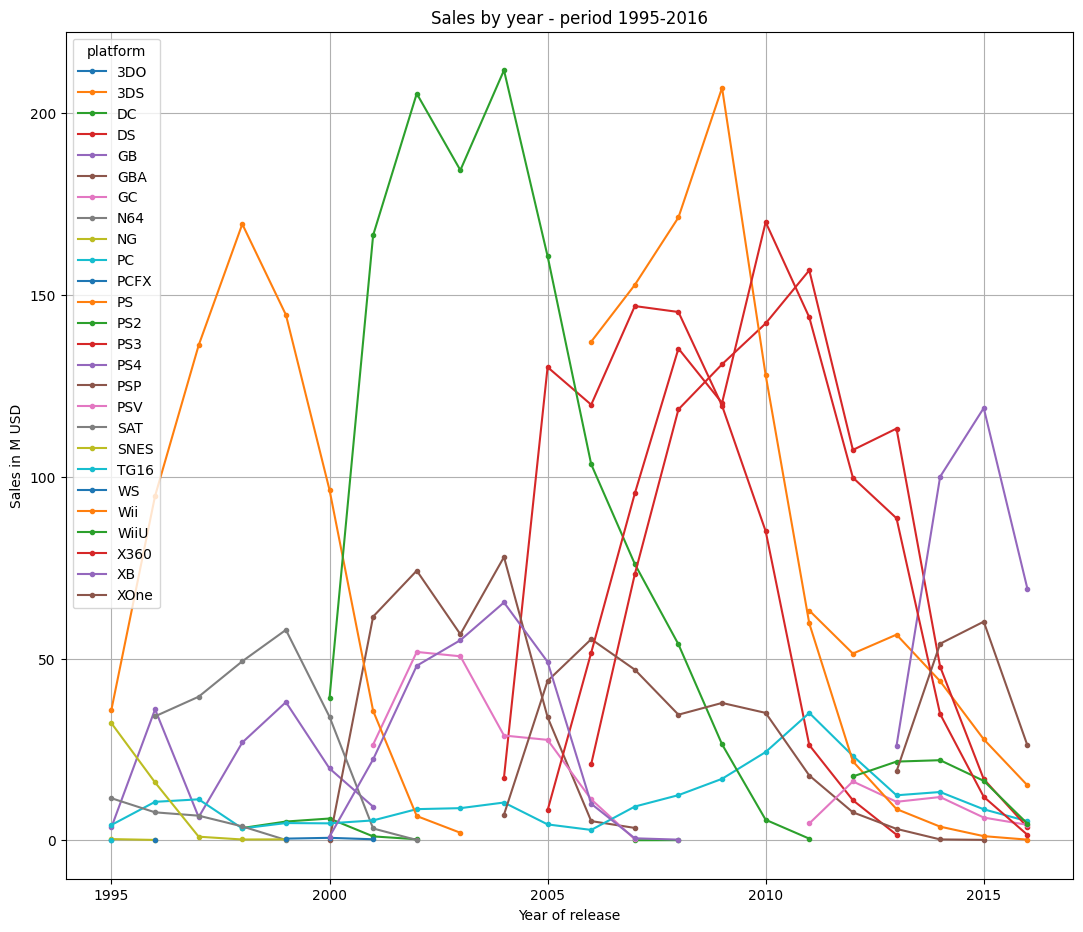

In [ ]:
# Analisis de plataformas en periodo 1995 a 2016
platform_filtered_per_year = games[(games['year_of_release'] > 0) & (games['year_of_release'] > 1994)]
platform_filtered_popularity_by_year = pd.pivot_table(platform_filtered_per_year, index=['year_of_release'],columns='platform',values='total_sales',aggfunc='sum')
print(platform_filtered_popularity_by_year)
platform_filtered_popularity_by_year.plot(style='.-', figsize=(13,11))
plt.title('Sales by year - period 1995-2016')
plt.xlabel('Year of release')
plt.ylabel('Sales in M USD')
plt.grid()

Se detecta que las plataformas lideres en ventas son PS, PS2, PS3, Wii, X360, cada una teniendo sus picos de ventas en diferentes años. Aunque las ventas de PS terminaron en 2003, PS2 en 2011, Wii en 2016 y para PS3 y X360 las ventas ya son muy bajas. <br>
Se observa que PC se mantiene constantemente con ventas sin llegar a tener ventas exhorbitantes. <br>
La eleccion de una plataforma en particular tambien dependera del area en la que se vendera pero basado unicamente en el grafico anterior se puede optar por elegir PS o bien plataformas de Nintendo y XBox.

<AxesSubplot:title={'center':'total_sales'}, xlabel='platform'>

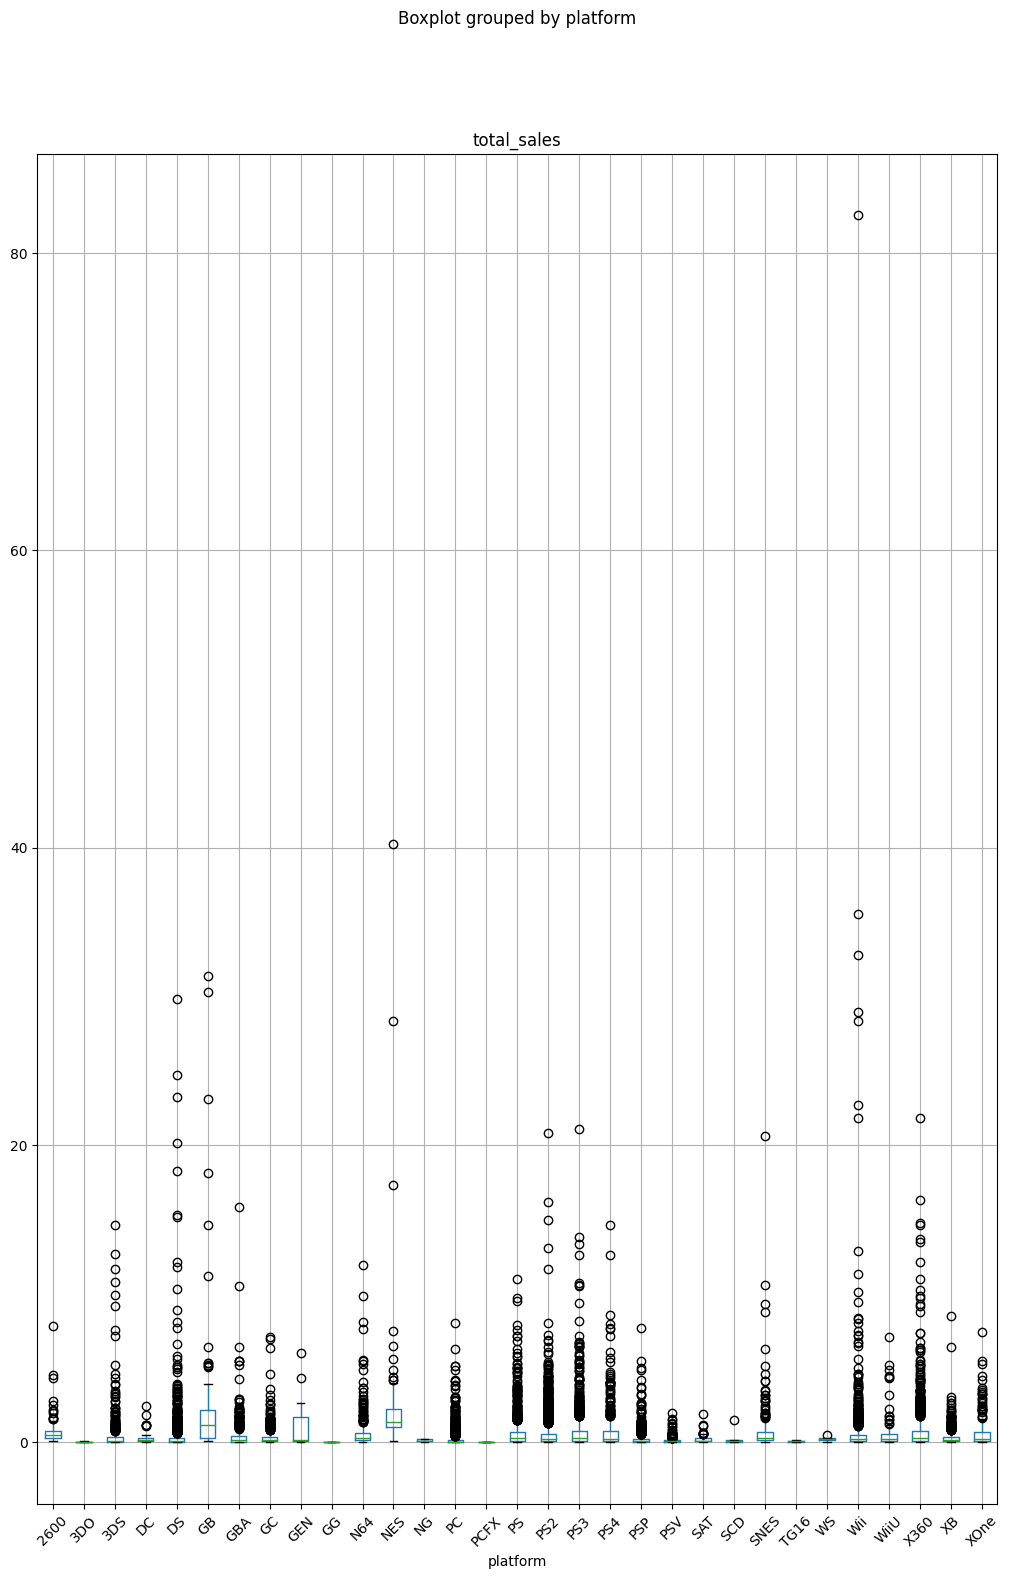

In [ ]:
#Box plot para ventas globales de todos los juegos por plataforma
games.boxplot(column='total_sales',by='platform',figsize=(12,18),rot=45)

Se observa un box plot mas definido para GB, NES y GEN, para el resto existen muchos valores atipicos que hacen que no este bien definido el box plot. La gran mayoria de las ventas promedio en varias plataformas se encuentra muy cerca del 0, esto en gran medida por la gran cantidad de ventas menores a 1 millon de USD de varios juegos. 

                 year_of_release  na_sales  eu_sales  jp_sales  other_sales  \
year_of_release         1.000000  0.012457  0.017610  0.023568     0.015271   
na_sales                0.012457  1.000000  0.840590  0.468787     0.728123   
eu_sales                0.017610  0.840590  1.000000  0.520103     0.718046   
jp_sales                0.023568  0.468787  0.520103  1.000000     0.396889   
other_sales             0.015271  0.728123  0.718046  0.396889     1.000000   
critic_score            0.013954  0.240755  0.220752  0.152593     0.198554   
user_score              0.027893  0.128364  0.111822  0.121859     0.106924   
total_sales             0.017840  0.955713  0.938932  0.613569     0.805501   

                 critic_score  user_score  total_sales  
year_of_release      0.013954    0.027893     0.017840  
na_sales             0.240755    0.128364     0.955713  
eu_sales             0.220752    0.111822     0.938932  
jp_sales             0.152593    0.121859     0.613569  
oth

<AxesSubplot:xlabel='critic_score', ylabel='total_sales'>

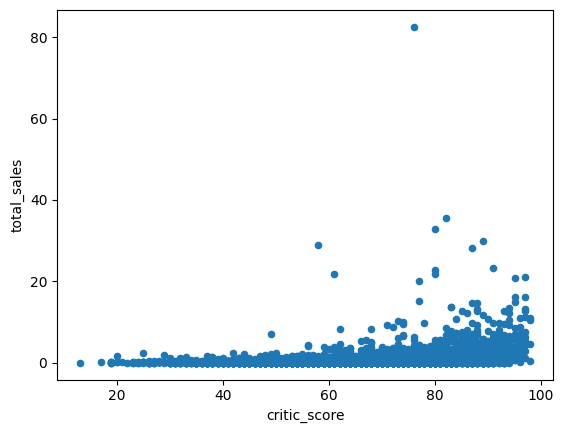

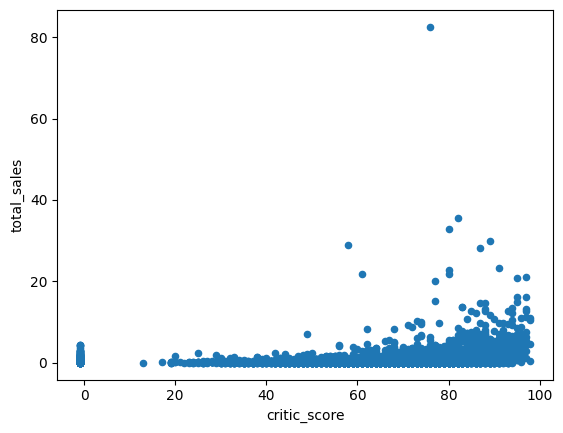

In [ ]:
#Analisis de reseñas de usuario y criticos vs las ventas de la plataforma PS2
PS2_platform = games[(games['platform'] == 'PS2')]
PS2_platform_critic = games[games['critic_score'] > 0] 
PS2_platform_user = games[games['user_score'] > 0]
print(PS2_platform_critic.corr(method='pearson',min_periods=100))
PS2_platform_critic.plot(kind='scatter',x='critic_score',y='total_sales')
print(PS2_platform_user.corr(method='pearson',min_periods=100))
PS2_platform_user.plot(kind='scatter',x='critic_score',y='total_sales')

No se nota una correlacion fuerte entre las criticas de usuarios y criticos con respecto a la ventas para el caso de la plataforma PS2, que es la que genera mayor cantidad de ventas. 

In [ ]:
# Analisis de ventas de juegos 
sales_by_game_platforms = pd.pivot_table(games, index=['name'],columns='platform',values='total_sales',aggfunc='sum').reset_index()
sales_by_game_platforms['total_sales'] = sales_by_game_platforms.sum(axis=1)
print(sales_by_game_platforms.sort_values(by='total_sales',ascending=False))


platform                                            name  2600  3DO   3DS  DC  \
11072                                         Wii Sports   NaN  NaN   NaN NaN   
3742                                  Grand Theft Auto V   NaN  NaN   NaN NaN   
9386                                   Super Mario Bros.   NaN  NaN   NaN NaN   
9775                                              Tetris   NaN  NaN   NaN NaN   
5611                                      Mario Kart Wii   NaN  NaN   NaN NaN   
...                                                  ...   ...  ...   ...  ..   
9522                                  Sweet Honey Coming   NaN  NaN   NaN NaN   
5533            Mahou Sensei Negima!? Neo-Pactio Fight!!   NaN  NaN   NaN NaN   
5911                            Mezase!! Tsuri Master DS   NaN  NaN   NaN NaN   
4203      Horse Life 4: My Horse, My Friend, My Champion   NaN  NaN  0.01 NaN   
3437                                    G1 Jockey 4 2008   NaN  NaN   NaN NaN   

platform    DS     GB  GBA 

Text(0, 0.5, 'Sales in M USD')

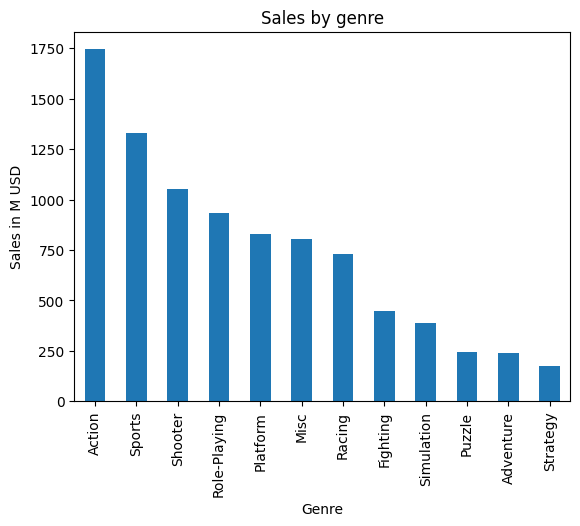

In [ ]:
# Analisis a distribucion por genero
sales_by_genre = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False).reset_index()
sales_by_genre.plot(kind='bar',x='genre',y='total_sales',legend=False)
plt.title('Sales by genre')
plt.xlabel('Genre')
plt.ylabel('Sales in M USD')

Se nota que los generos de action, sports y shooter son los que destacan de los demas en cuanto a ventas, lo cual no sorprende puesto que dia a dia en cualquier plataforma son los juegos que mas ingresos generan. <br>
Los que menos venden son los de puzzle, adventure y strategy. 

# 4. Perfil de usuario por region

**Se analizara el perfil de usuario para la region de North America**

<AxesSubplot:title={'center':'North America sales by platform'}, xlabel='Platform', ylabel='Sales in M USD'>

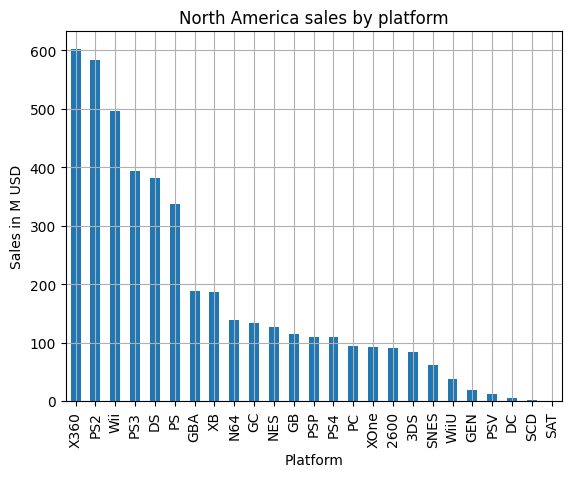

In [ ]:
# Analisis de plataformas principales
NA_data = games[games['na_sales'] > 0]
NA_platform = pd.pivot_table(NA_data, index='platform',values='na_sales',aggfunc='sum').sort_values(by='na_sales',ascending=False).reset_index()
NA_platform.plot(kind='bar',x='platform',y='na_sales',legend=False,title='North America sales by platform',xlabel='Platform',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'North America sales by genre'}, xlabel='Genre', ylabel='Sales in M USD'>

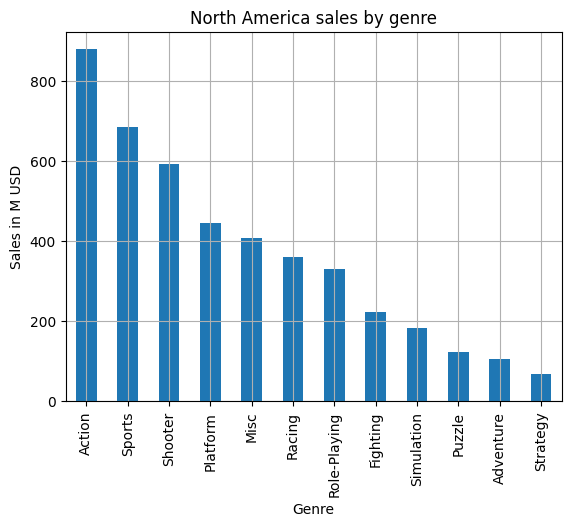

In [ ]:
# analisis de generos principales
NA_genre = pd.pivot_table(NA_data, index='genre',values='na_sales',aggfunc='sum').sort_values(by='na_sales',ascending=False).reset_index()
NA_genre.plot(kind='bar',x='genre',y='na_sales',legend=False,title='North America sales by genre',xlabel='Genre',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'North America sales by rating'}, xlabel='Rating', ylabel='Sales in M USD'>

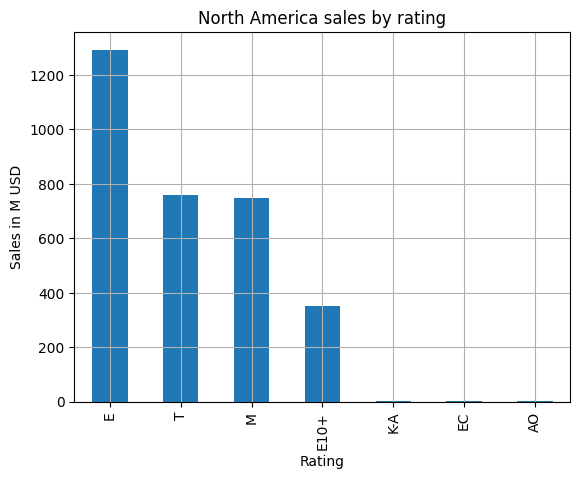

In [ ]:
# Analisis de clasificacion y ventas
NA_rating = pd.pivot_table(NA_data[NA_data['rating'] != 'unknown'], index='rating',values='na_sales',aggfunc='sum').sort_values(by='na_sales',ascending=False).reset_index()
NA_rating.plot(kind='bar',x='rating',y='na_sales',legend=False,title='North America sales by rating',xlabel='Rating',ylabel='Sales in M USD',grid=True)

**Se analizara el perfil de usuario para la region de Europe**

<AxesSubplot:title={'center':'Europe sales by platform'}, xlabel='Platform', ylabel='Sales in M USD'>

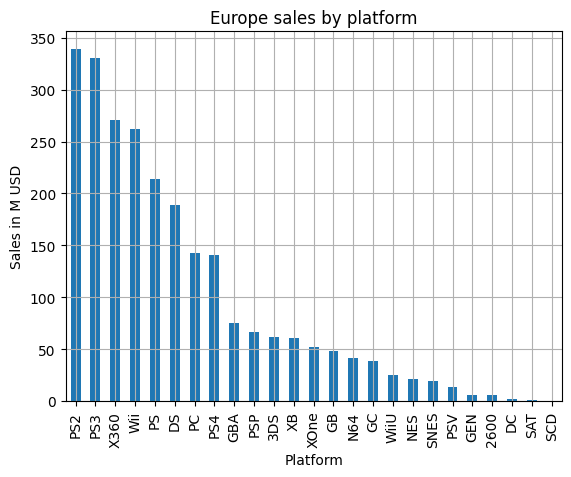

In [ ]:
# Analisis de plataformas principales
EU_data = games[games['eu_sales'] > 0]
EU_platform = pd.pivot_table(EU_data, index='platform',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales',ascending=False).reset_index()
EU_platform.plot(kind='bar',x='platform',y='eu_sales',legend=False,title='Europe sales by platform',xlabel='Platform',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'Europe sales by genre'}, xlabel='Genre', ylabel='Sales in M USD'>

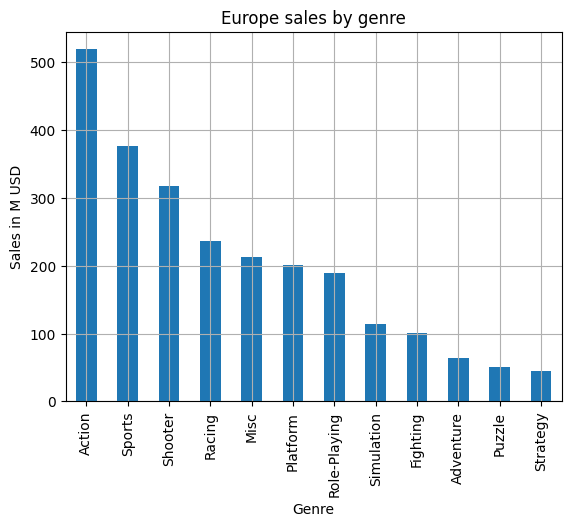

In [ ]:
# analisis de generos principales
EU_genre = pd.pivot_table(EU_data, index='genre',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales',ascending=False).reset_index()
EU_genre.plot(kind='bar',x='genre',y='eu_sales',legend=False,title='Europe sales by genre',xlabel='Genre',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'Europe sales by rating'}, xlabel='Rating', ylabel='Sales in M USD'>

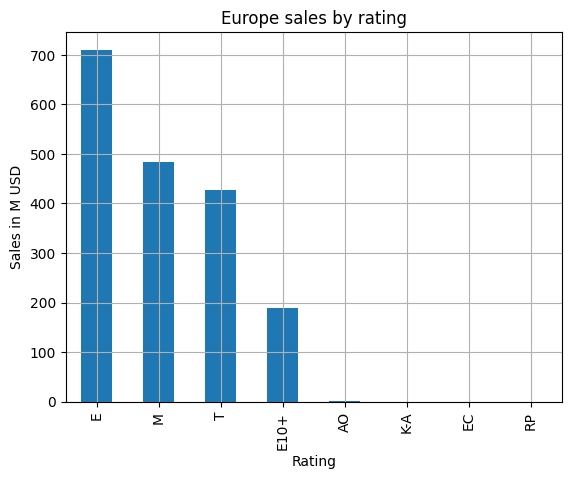

In [ ]:
# Analisis de clasificacion y ventas
EU_rating = pd.pivot_table(EU_data[EU_data['rating'] != 'unknown'], index='rating',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales',ascending=False).reset_index()
EU_rating.plot(kind='bar',x='rating',y='eu_sales',legend=False,title='Europe sales by rating',xlabel='Rating',ylabel='Sales in M USD',grid=True)

**Se analizara el perfil de usuario para la region de Japan**

<AxesSubplot:title={'center':'Japan sales by platform'}, xlabel='Platform', ylabel='Sales in M USD'>

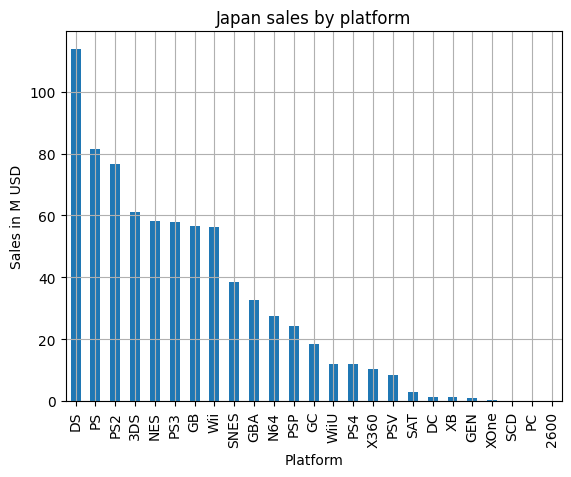

In [ ]:
# Analisis de plataformas principales
JP_data = games[games['jp_sales'] > 0]
JP_platform = pd.pivot_table(EU_data, index='platform',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales',ascending=False).reset_index()
JP_platform.plot(kind='bar',x='platform',y='jp_sales',legend=False,title='Japan sales by platform',xlabel='Platform',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'Japan sales by genre'}, xlabel='Genre', ylabel='Sales in M USD'>

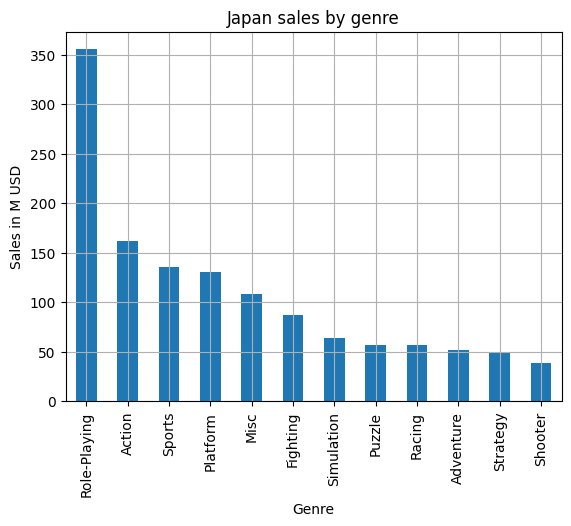

In [ ]:
# analisis de generos principales
JP_genre = pd.pivot_table(JP_data, index='genre',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales',ascending=False).reset_index()
JP_genre.plot(kind='bar',x='genre',y='jp_sales',legend=False,title='Japan sales by genre',xlabel='Genre',ylabel='Sales in M USD',grid=True)

<AxesSubplot:title={'center':'Japan sales by rating'}, xlabel='Rating', ylabel='Sales in M USD'>

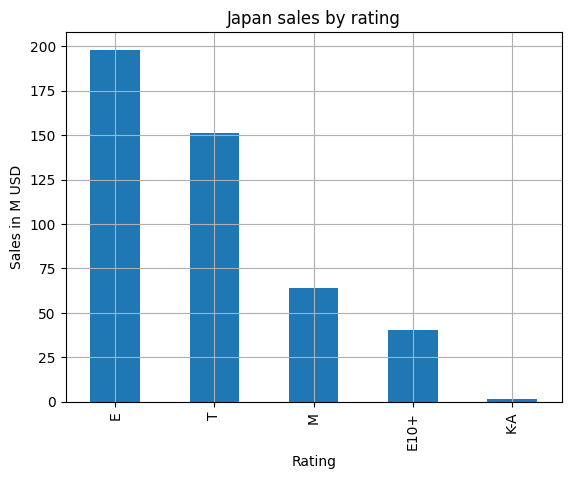

In [ ]:
# Analisis de clasificacion y ventas
JP_rating = pd.pivot_table(JP_data[JP_data['rating'] != 'unknown'], index='rating',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales',ascending=False).reset_index()
JP_rating.plot(kind='bar',x='rating',y='jp_sales',legend=False,title='Japan sales by rating',xlabel='Rating',ylabel='Sales in M USD',grid=True)

Analisis de resultados anteriores por perfil de usuario: <br>
1. Para el caso de las cinco plataformas principales, se observa lo siguiente: <br>
   a. Para Norteamerica son: X360, PS2, Wii, PS3, DS <br>
   b. Para Europa son: PS2, PS3, X360, Wii, PS <br>
   c. Para Japon son: DS, PS, PS2, 3DS, NES, PS3 <br>
   Se observa que PS en cualquiera de sus generaciones se vende en todas las regiones. X360 unicamente destaca en ventas en Norteamerica y Europa pero no en Japon. La ventas de Wii solo destacan en Norteamerica y Europa pero no en Japon. <br>
   <br>
2. Para el caso de los generos principales, se observa lo siguiente: <br>
   a. Para Norteamerica son: Action, Sports, Shooter, Platform, Misc <br>
   b. Para Europa son: Action, Sports, Shooter, Racing, Misc <br>
   c. Para Japon son: Role-playing, Action, Sports, Platform, Misc <br>
   Se observa que entre Norteamerica y Europa son practicamente los mismos generos que generan mayores ventas y para Japon las cosas cambian en cuanto al primer lugar de ventas, de ahi en fuera se asemeja mucho con las otras dos regiones. <br>
   <br>
3. Para el caso de las clasificaciones ESRB y las ventas en las regiones, se observa lo siguiente: <br>
   a. Para el caso de Norteamerica son: E (1300), T (750), M (740), E10+ (350) <br>
   b. Para el caso de Europa son: E (720), M (480), T (425), E10+ (190) <br>
   c. Para el caso de Japon son: E (190), T (160), M (60), E10+ (40) <br>
   Se observa que practicamente el numero uno de ventas en todas las regiones son las clasificaciones E y tanto en Japon como Norteamerica le siguen las clasificacion T mientras que en Europa es la M y en todas la cuarta es la clasificacion E10+.

# 5. Pruebas de hipotesis

**Analisis de calificaciones promedio de usuarios para plataformas Xbox One y PC son iguales** <br>
H0: Calificaciones promedio de usuarios para Xbox One y PC son iguales <br>
H1: Calificaciones promedio de usuarios para Xbox One y PC son diferentes <br>

Se hara un analisis de dos colas para dos muestras independientes de calificaciones promedio de usuarios con un alfa de 5%

In [ ]:
# Prueba de hipotesis
user_score_XOne = games[(games['platform'] == 'XOne') & (games['user_score'] > 0)]['user_score']
user_score_PC = games[(games['platform'] == 'PC') & (games['user_score'] > 0)]['user_score']
stat, p = st.levene(user_score_XOne,user_score_PC)
print(f"Prueba de Levene(p-value): {p}")
print()

alpha=0.05
t_stat, p_val_2tail = ttest_ind(user_score_XOne,user_score_PC)
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_val_2tail}")

if p_val_2tail < alpha:
    print("Se rechaza la hipótesis nula. Las calificaciones de XBoxOne y PC son diferentes.")
else:
    print("No se rechaza la hipótesis nula. No hay suficientes evidencias para concluir que las calificaciones de XBoxOne y PC sean diferentes.")

Prueba de Levene(p-value): 0.2693951512047048

t-statistic: -4.368333815003015
p-value: 1.3896435533548819e-05
Se rechaza la hipótesis nula. Las calificaciones de XBoxOne y PC son diferentes.


**Analisis de calificaciones promedio de usuarios para genero de Action y Sports son diferentes** <br>
H0: Calificaciones promedio de usuarios genero de Action y Sports son iguales <br>
H1: Calificaciones promedio de usuarios genero de Action y Sports son diferentes <br>

Se hara un analisis de dos colas para dos muestras independientes de calificaciones promedio de usuarios con un alfa de 5%

In [ ]:
# Prueba de hipotesis
user_score_action = games[(games['genre'] == 'Action') & (games['user_score'] > 0)]['user_score']
user_score_sports = games[(games['genre'] == 'Sports') & (games['user_score'] > 0)]['user_score']
stat, p = st.levene(user_score_action,user_score_sports)
print(f"Prueba de Levene(p-value): {p}")
print()

alpha=0.05
t_stat, p_val_2tail = ttest_ind(user_score_action,user_score_sports,equal_var=False)
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_val_2tail}")

if p_val_2tail < alpha:
    print("Se rechaza la hipótesis nula. Las calificaciones de los generos Action y Sports son diferentes.")
else:
    print("No se rechaza la hipótesis nula. No hay suficientes evidencias para concluir que las calificaciones de los generos Action y Sports sean diferentes.")

Prueba de Levene(p-value): 0.0001736640672727649

t-statistic: 1.57746791633354
p-value: 0.11483818791498286
No se rechaza la hipótesis nula. No hay suficientes evidencias para concluir que las calificaciones de los generos Action y Sports sean diferentes.


# 6. Conclusiones generales

En este proyecto se verifico el comportamiento de las ventas de diferentes plataformas de videojuegos a traves del tiempo para poder definir una estrategia de marketing para el año venidero. <br>
Se consideraron varios aspectos a analizar para poder tomar una decision mas informada, es por eso que se consideraron los siguientes analisis como la venta de videojuegos por año, las ventas totales de cada plataforma, las ventas de cada plataforma por año para poder definir el periodo a analizar detenidamente. <br>
Posteriormente se incluyo que tanto influyen las criticas de usuarios o de criticos en las ventas, asi como la ventas por genero y las ventas de juegos por diferentes plataformas.
Para finalizar se verificaron las ventas de plataformas, genero y rating por region. Dentro del analisis final se incluyeron pruebas de hipotesis para las calificaciones promedio de usuarios entre las plataformas Xbone y PC y los generos Action y Sports. <br>

Se puede concluir que una buena estrategia es apostar por la venta de las plataformas PS en cualquier region, Nintendo especialmente en Japon y de Xbox para Norteamerica y Europa principalmente. Tambien se sugiere que los generos mas recomendados son los Action, Sports, Role-playing (especialmete para Japon), Shooter (especialmente Europa y Norteamerica) y Platform (especialmente Japon y Norteamerica) para practicamente cualquier region. Si se requiere alguna clasificacion en particular se recomienda enfocarse en las E, T y M para toda las regiones. 